# 2D Unconstrained Demand Estimation (Weight & Volume): Model Evaluation

> **Abstract:** This notebook evaluates a suite of unconstrained demand estimation models across five cargo segments (Contract, General, Perishable, Express, Spot) over 90 Origin–Destination routes. Models include baseline methods (Naïve, EM, EM+Price) and Projection-Detruncation variants (PD) at eight fractile levels $\\tau \\in \\{0.2, \\ldots, 0.9\\}$, with and without price covariates. Performance is assessed via WAPE, RMSE, MAE, and $R^2$.

---
## 0 · Environment Setup

In [1]:
import pandas as pd
import glob
import numpy as np
import os
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

# ── Thesis-Quality Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    # Font
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "DejaVu Serif", "Georgia"],
    "font.size":           10,
    # Axes
    "axes.titlesize":      11,
    "axes.titleweight":    "bold",
    "axes.titlepad":       8,
    "axes.labelsize":      10,
    "axes.labelpad":       4,
    "axes.linewidth":      0.7,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    # Ticks
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "xtick.direction":     "out",
    "ytick.direction":     "out",
    "xtick.major.size":    3,
    "ytick.major.size":    3,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    # Legend
    "legend.fontsize":     8.5,
    "legend.framealpha":   0.95,
    "legend.edgecolor":    "#cccccc",
    "legend.borderpad":    0.5,
    # Grid
    "axes.grid":           True,
    "grid.linestyle":      "--",
    "grid.linewidth":      0.45,
    "grid.color":          "#d8d8d8",
    # Figure
    "figure.dpi":          150,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "savefig.pad_inches":  0.05,
    "figure.constrained_layout.use": False,
})

# ── Colour Palettes ───────────────────────────────────────────────────────────
# Neutral academic palette for time series
TS_COLORS = {
    "Oracle":   "#1a1a2e",   # Deep navy
    "Observed": "#c0392b",   # Muted red
    "Estimate": "#2e6da4",   # Steel blue
}

# Categorical palette for model comparisons (colorblind-friendly)
MODEL_PALETTE = {
    "Naive":       "#555555",
    "EM":          "#2e6da4",
    "EMXPrice":    "#4e9fcf",
    "PD05":        "#d4691e",
    "PDXPrice05":  "#e8a44a",
    "PD07":        "#2e7d32",
    "PDXPrice07":  "#66bb6a",
    "MoE":         "#e91e63",
}

# Sequential palette for heatmaps
HEATMAP_CMAP = "RdYlGn_r"

print("Environment ready.")

Environment ready.


---
## 1 · Configuration

In [2]:
FILTER_ZEROS = False
SEGMENTS     = ["Contract", "General", "Perishable", "Express", "Spot"]

# Models
MODELS    = ["MoE", "Naive", "EM", "EMXPrice"]
TAU_VALUES = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for tau in TAU_VALUES:
    tau_str = str(tau).replace('.', '')
    MODELS.extend([f"PD{tau_str}", f"PDXPrice{tau_str}"])

# Friendly display names
MODEL_LABELS = {
    "MoE":        "Mixture of Experts (Dynamic)",
    "Naive":      "Naïve",
    "EM":         "EM",
    "EMXPrice":   "EM + Price",
    **{f"PD{str(t).replace('.','')}": f"PD ($\\tau$={t})" for t in TAU_VALUES},
    **{f"PDXPrice{str(t).replace('.','')}": f"PD+Price ($\\tau$={t})" for t in TAU_VALUES},
}

print(f"Total models: {len(MODELS)}")
print(f"Segments:     {SEGMENTS}")

Total models: 20
Segments:     ['Contract', 'General', 'Perishable', 'Express', 'Spot']


---
## 2 · Data Ingestion & Preprocessing

In [3]:
def trim_burn_in(df_group):
    """Remove leading rows until all model estimates are available."""
    est_cols = [
        f"{m}_{s}_Est_kg" for m in MODELS for s in SEGMENTS
        if f"{m}_{s}_Est_kg" in df_group.columns
    ]
    if not est_cols:
        return pd.DataFrame()
    valid_mask = df_group[est_cols].notna().all(axis=1)
    if not valid_mask.any():
        return pd.DataFrame()
    return df_group.loc[valid_mask.idxmax():].copy()


files = glob.glob("./results/unconstrained_3yr/*.parquet")
files = glob.glob("./results/probabilistic_unconstrained_3yr/*.parquet")
print(f"Found {len(files)} parquet files.")

df_all = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print(f"Raw shape: {df_all.shape}")

print("Trimming burn-in period …")
df_trimmed = (
    df_all
    .groupby(["Origin", "Destination"], as_index=False, group_keys=False)
    .apply(trim_burn_in)
)

# ── Aggregate Totals ──────────────────────────────────────────────────────────
print("Aggregating totals …")
df_trimmed["Total_Oracle_kg"]   = 0.0
df_trimmed["Total_Observed_kg"] = 0.0
for m in MODELS:
    df_trimmed[f"{m}_Total_Est"] = 0.0

for s in SEGMENTS:
    obs_col    = f"Observed_{s}_kg"
    oracle_col = f"Oracle_{s}_kg"
    df_trimmed["Total_Oracle_kg"]   += df_trimmed[oracle_col].fillna(0)
    df_trimmed["Total_Observed_kg"] += df_trimmed[obs_col].fillna(0)
    for m in MODELS:
        est_col = f"{m}_{s}_Est_kg"
        df_trimmed[est_col] = df_trimmed[est_col].fillna(df_trimmed[obs_col])
        df_trimmed[f"{m}_Total_Est"] += df_trimmed[est_col]

df_analysis = df_trimmed.reset_index(drop=True)
print(f"Analysis dataset: {df_analysis.shape[0]:,} rows × {df_analysis.shape[1]} cols")

Found 180 parquet files.
Raw shape: (197280, 381)
Trimming burn-in period …
Aggregating totals …
Analysis dataset: 164,430 rows × 402 cols


---
## 3 · Metric Computation

In [4]:
EVAL_SEGMENTS = SEGMENTS + ["Total"]
route_results = []

for (o, d), g in df_analysis.groupby(["Origin", "Destination"]):
    for seg in EVAL_SEGMENTS:
        true_col   = f"Oracle_{seg}_kg" if seg != "Total" else "Total_Oracle_kg"
        yt         = g[true_col].values
        avg_demand = np.nanmean(yt) if np.isfinite(yt).any() else 0.0

        for model in MODELS:
            est_col = f"{model}_{seg}_Est_kg" if seg != "Total" else f"{model}_Total_Est"
            yp      = g[est_col].values
            mask    = ~np.isnan(yt) & ~np.isnan(yp)
            if mask.sum() < 2:
                continue
            yt_v, yp_v = yt[mask], yp[mask]

            mae  = np.mean(np.abs(yt_v - yp_v))
            rmse = np.sqrt(mean_squared_error(yt_v, yp_v))
            wape = (np.sum(np.abs(yt_v - yp_v)) / np.sum(np.abs(yt_v))) * 100 \
                   if np.sum(np.abs(yt_v)) > 0 else np.nan
            r2   = r2_score(yt_v, yp_v)

            route_results.append({
                "Origin": o, "Destination": d,
                "Segment": seg, "Model": model,
                "Avg_Oracle_Demand": avg_demand,
                "MAE": mae, "RMSE": rmse, "WAPE": wape, "R2": r2,
            })

df_route_metrics = pd.DataFrame(route_results)
summary_df = df_route_metrics.groupby(["Model", "Segment"])[["MAE", "RMSE", "WAPE", "R2"]].mean()

print(f"Route-level metrics computed: {len(route_results):,} records")

Route-level metrics computed: 10,800 records


---
## 4 · Table 1: Global WAPE by Segment

Mean WAPE (%) aggregated over all routes for each model–segment combination. Lower is better.

In [5]:
wape_pivot = (
    summary_df
    .reset_index()
    .pivot(index="Model", columns="Segment", values="WAPE")
    [EVAL_SEGMENTS]
    .round(2)
)

print("Table 1 — Global WAPE (%) by Segment")
print("=" * 60)
display(wape_pivot.style
    .format("{:.2f}")
    .background_gradient(cmap="RdYlGn_r", axis=0)
    .set_caption("Table 1. Mean WAPE (%) per model and cargo segment.")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-style', 'italic'), ('font-size', '10px'), ('text-align', 'left')]
    }])
)

Table 1 — Global WAPE (%) by Segment


Segment,Contract,General,Perishable,Express,Spot,Total
Model,,,,,,
EM,2.88,3.22,3.97,5.39,4.39,2.95
EMXPrice,2.91,3.03,3.97,5.39,4.08,2.88
MoE,1.32,2.49,3.87,6.12,2.99,2.25
Naive,0.61,2.50,5.15,12.64,2.26,3.59
PD02,6.65,6.01,5.94,5.57,8.41,6.02
PD03,4.08,4.00,4.44,5.20,5.61,3.84
PD04,2.90,3.24,3.99,5.36,4.44,2.98
PD05,2.19,2.85,3.85,5.61,3.80,2.56
PD06,1.71,2.64,3.83,5.88,3.42,2.35


---
## 5 · Table 2: Aggregate Metrics — Total Demand

Summary statistics for the Total (all-segment) demand estimation.

In [6]:
global_total = (
    summary_df
    .reset_index()
    [lambda df: df["Segment"] == "Total"]
    .set_index("Model")[["MAE", "RMSE", "WAPE", "R2"]]
    .round(3)
)

print("Table 2 — Global Aggregate Metrics (Total demand)")
print("=" * 60)
display(global_total.style
    .format({"MAE": "{:,.1f}", "RMSE": "{:,.1f}", "WAPE": "{:.3f}", "R2": "{:.3f}"})
    .background_gradient(subset=["WAPE", "MAE", "RMSE"], cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["R2"], cmap="RdYlGn", axis=0)
    .set_caption("Table 2. Aggregate performance metrics across all segments combined. WAPE and MAE: lower is better; R²: higher is better.")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-style', 'italic'), ('font-size', '10px'), ('text-align', 'left')]
    }])
)

Table 2 — Global Aggregate Metrics (Total demand)


,MAE,RMSE,WAPE,R2
Model,,,,
EM,"2,125.6","5,965.1",2.955,0.943
EMXPrice,"2,073.4","5,859.9",2.883,0.945
MoE,"1,613.2","5,417.9",2.249,0.953
Naive,"2,564.4","8,004.8",3.589,0.900
PD02,"4,415.1","10,720.1",6.024,0.793
PD03,"2,778.8","7,215.8",3.838,0.914
PD04,"2,147.0","6,000.6",2.982,0.942
PD05,"1,837.6","5,530.3",2.559,0.951
PD06,"1,686.4","5,396.4",2.352,0.954


---
## 6 · Figure 1: WAPE Sensitivity to Projection Fractile $\tau$

Both PD and PD+Price model families are shown. The optimal fractile minimises WAPE across all routes.

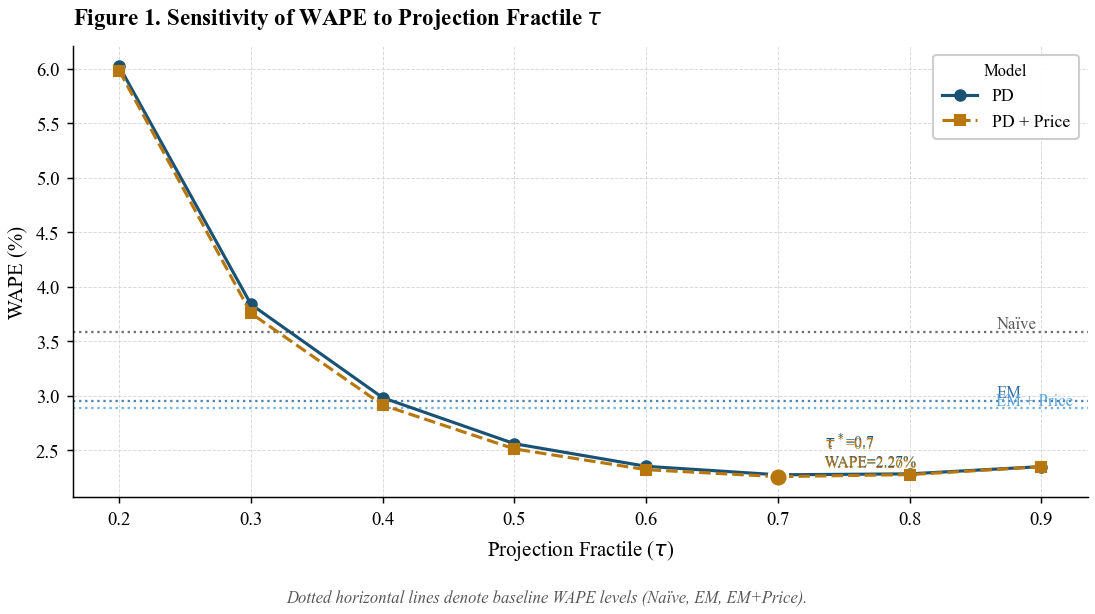

In [7]:
def extract_tau(model_name):
    m = re.search(r'(\d+)$', model_name)
    return float(m.group(1)) / 10.0 if m else None

pd_metrics = (
    summary_df
    .reset_index()
    .query("Segment == 'Total' and Model.str.startswith('PD')")
    .copy()
)
pd_metrics["Tau"]        = pd_metrics["Model"].apply(extract_tau)
pd_metrics["Model_Type"] = pd_metrics["Model"].apply(
    lambda x: "PD + Price" if "XPrice" in x else "PD"
)
pd_metrics = pd_metrics.sort_values("Tau")

# Optimal tau per family
opt_pd       = pd_metrics[pd_metrics["Model_Type"] == "PD"].nsmallest(1, "WAPE")
opt_pdxprice = pd_metrics[pd_metrics["Model_Type"] == "PD + Price"].nsmallest(1, "WAPE")

# Baseline references
ref_models  = ["Naive", "EM", "EMXPrice"]
ref_labels  = {"Naive": "Naïve", "EM": "EM", "EMXPrice": "EM + Price"}
ref_colors  = {"Naive": "#555555", "EM": "#2e6da4", "EMXPrice": "#5ba3d9"}
ref_metrics = (
    summary_df
    .reset_index()
    .query("Segment == 'Total' and Model in @ref_models")
    .set_index("Model")
)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.set_axisbelow(True)

# ── PD families ──
line_styles = {"PD": ("-", "#1a5276", "o"), "PD + Price": ("--", "#b7770d", "s")}
for mtype, (ls, col, marker) in line_styles.items():
    sub = pd_metrics[pd_metrics["Model_Type"] == mtype]
    ax.plot(sub["Tau"], sub["WAPE"], linestyle=ls, color=col,
            marker=marker, markersize=5, linewidth=1.5, label=mtype, zorder=4)

# ── Optimal markers ──
for opt, col in [(opt_pd, "#1a5276"), (opt_pdxprice, "#b7770d")]:
    ax.scatter(opt["Tau"], opt["WAPE"], color=col, s=80, zorder=6,
               edgecolors="white", linewidth=1.2)
    ax.annotate(f"  $\\tau^*$={opt['Tau'].values[0]:.1f}\n  WAPE={opt['WAPE'].values[0]:.2f}%",
                xy=(opt["Tau"].values[0], opt["WAPE"].values[0]),
                xytext=(opt["Tau"].values[0] + 0.03, opt["WAPE"].values[0] + 0.08),
                fontsize=7.5, color=col)

# ── Baseline reference lines ──
for m in ref_models:
    if m in ref_metrics.index:
        wape_val = ref_metrics.loc[m, "WAPE"]
        ax.axhline(wape_val, linestyle=":", linewidth=1.1,
                   color=ref_colors[m], alpha=0.85, zorder=2)
        ax.text(0.91, wape_val + 0.03, ref_labels[m], fontsize=8,
                color=ref_colors[m], transform=ax.get_yaxis_transform())

ax.set_xlabel("Projection Fractile ($\\tau$)")
ax.set_ylabel("WAPE (%)")
ax.set_title("Figure 1. Sensitivity of WAPE to Projection Fractile $\\tau$",
             loc="left", pad=10)
ax.set_xticks(TAU_VALUES)
ax.legend(title="Model", title_fontsize=8, loc="upper right")
fig.text(0.5, -0.03,
         "Dotted horizontal lines denote baseline WAPE levels (Naïve, EM, EM+Price).",
         ha="center", fontsize=8, color="#555555", style="italic")
plt.tight_layout()
plt.savefig("fig1_wape_tau_sensitivity_2dim.pdf")
plt.show()

---
## 7 · Figure 2: Model Performance Dashboard (Total Demand)

Four-panel overview comparing all key metrics for a curated model set.

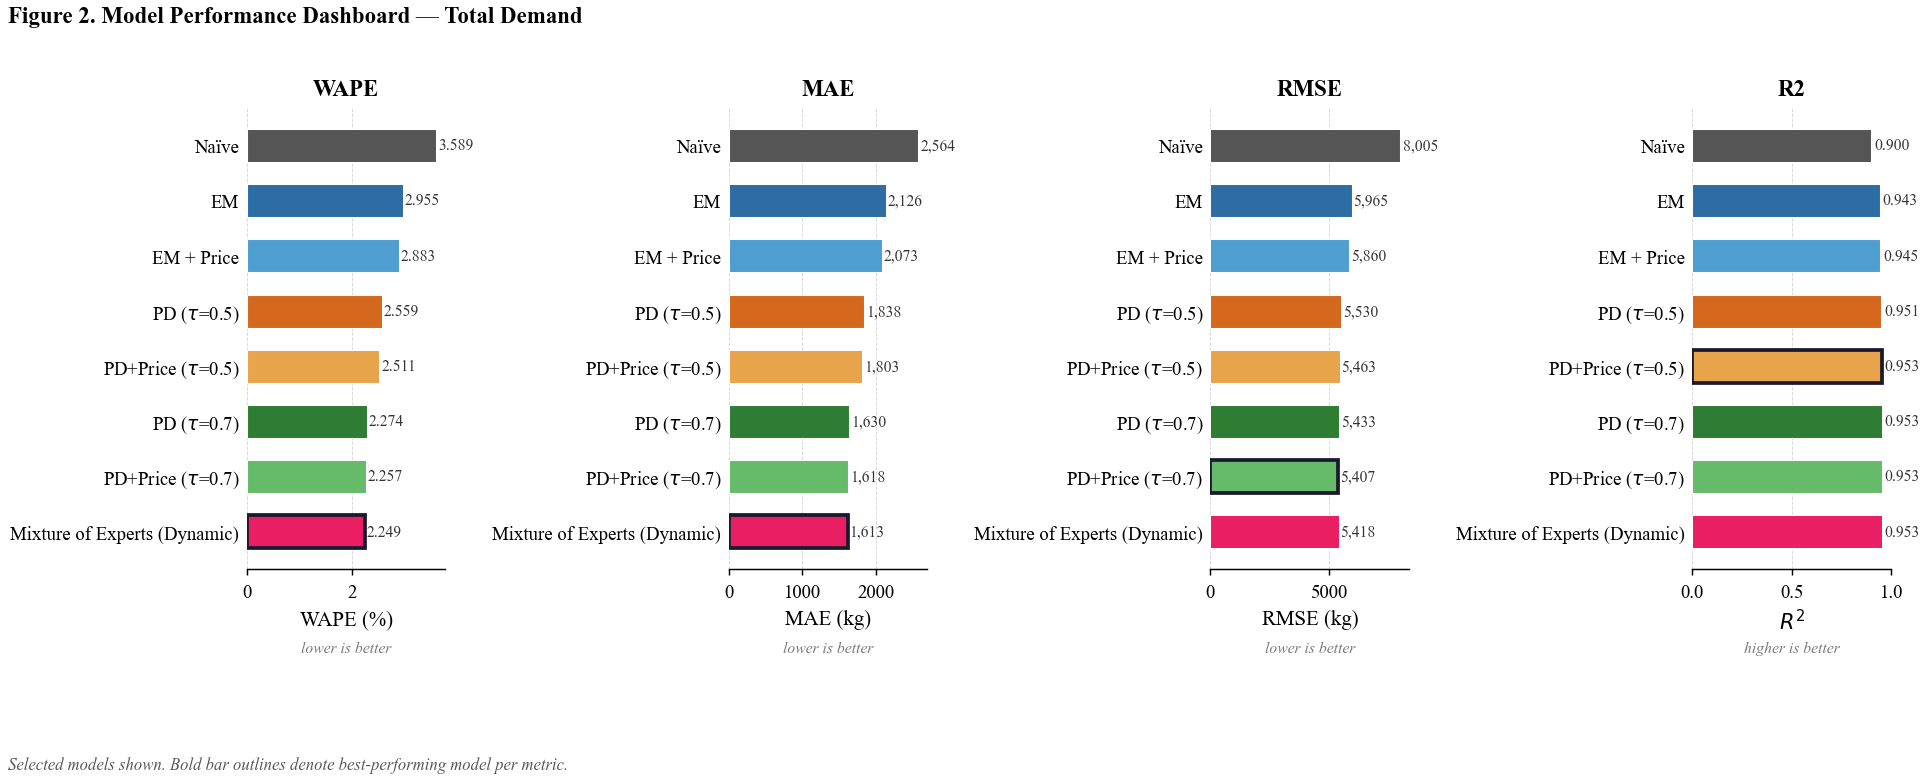

In [8]:
TARGET_MODELS = ["Naive", "EM", "EMXPrice", "PD05", "PDXPrice05", "PD07", "PDXPrice07", "MoE"]
TARGET_LABELS = [MODEL_LABELS.get(m, m) for m in TARGET_MODELS]
TARGET_COLORS = [MODEL_PALETTE.get(m, "#aaaaaa") for m in TARGET_MODELS]

panel_data = (
    global_total
    .reset_index()
    .query("Model in @TARGET_MODELS")
    .set_index("Model")
    .loc[TARGET_MODELS]
)

METRICS = [
    ("WAPE",  "WAPE (%)",       False, "lower is better"),
    ("MAE",   "MAE (kg)",       False, "lower is better"),
    ("RMSE",  "RMSE (kg)",      False, "lower is better"),
    ("R2",    "$R^2$",          True,  "higher is better"),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))

for ax, (metric, ylabel, higher_better, note) in zip(axes, METRICS):
    vals   = panel_data[metric].values
    bars   = ax.barh(TARGET_LABELS[::-1], vals[::-1], color=TARGET_COLORS[::-1],
                     edgecolor="white", linewidth=0.5, height=0.6)
    # Value annotations
    for bar, val in zip(bars, vals[::-1]):
        fmt = f"{val:,.0f}" if metric in ("MAE", "RMSE") else f"{val:.3f}"
        ax.text(bar.get_width() + bar.get_width() * 0.015, bar.get_y() + bar.get_height() / 2,
                fmt, va="center", ha="left", fontsize=7.5, color="#333333")

    ax.set_xlabel(ylabel)
    ax.set_title(metric, pad=6)
    ax.text(0.5, -0.18, note, transform=ax.transAxes, ha="center",
            fontsize=7.5, color="#777777", style="italic")
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", linestyle="--", linewidth=0.45, color="#d8d8d8")
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    # Highlight best bar
    best_idx = int(np.argmax(vals) if higher_better else np.argmin(vals))
    bars[len(TARGET_MODELS) - 1 - best_idx].set_edgecolor("#1a1a2e")
    bars[len(TARGET_MODELS) - 1 - best_idx].set_linewidth(1.8)

fig.suptitle("Figure 2. Model Performance Dashboard — Total Demand",
             x=0.01, ha="left", fontsize=11, fontweight="bold", y=1.01)
fig.text(0.01, -0.12,
         "Selected models shown. Bold bar outlines denote best-performing model per metric.",
         fontsize=8, color="#555555", style="italic")
plt.tight_layout()
plt.savefig("fig2_model_dashboard_2dim.pdf")
plt.show()

---
## 8 · Figure 3: WAPE Heatmap — All Models × Segments

A structured heatmap for rapid visual diagnosis of where each model excels or underperforms across segments.

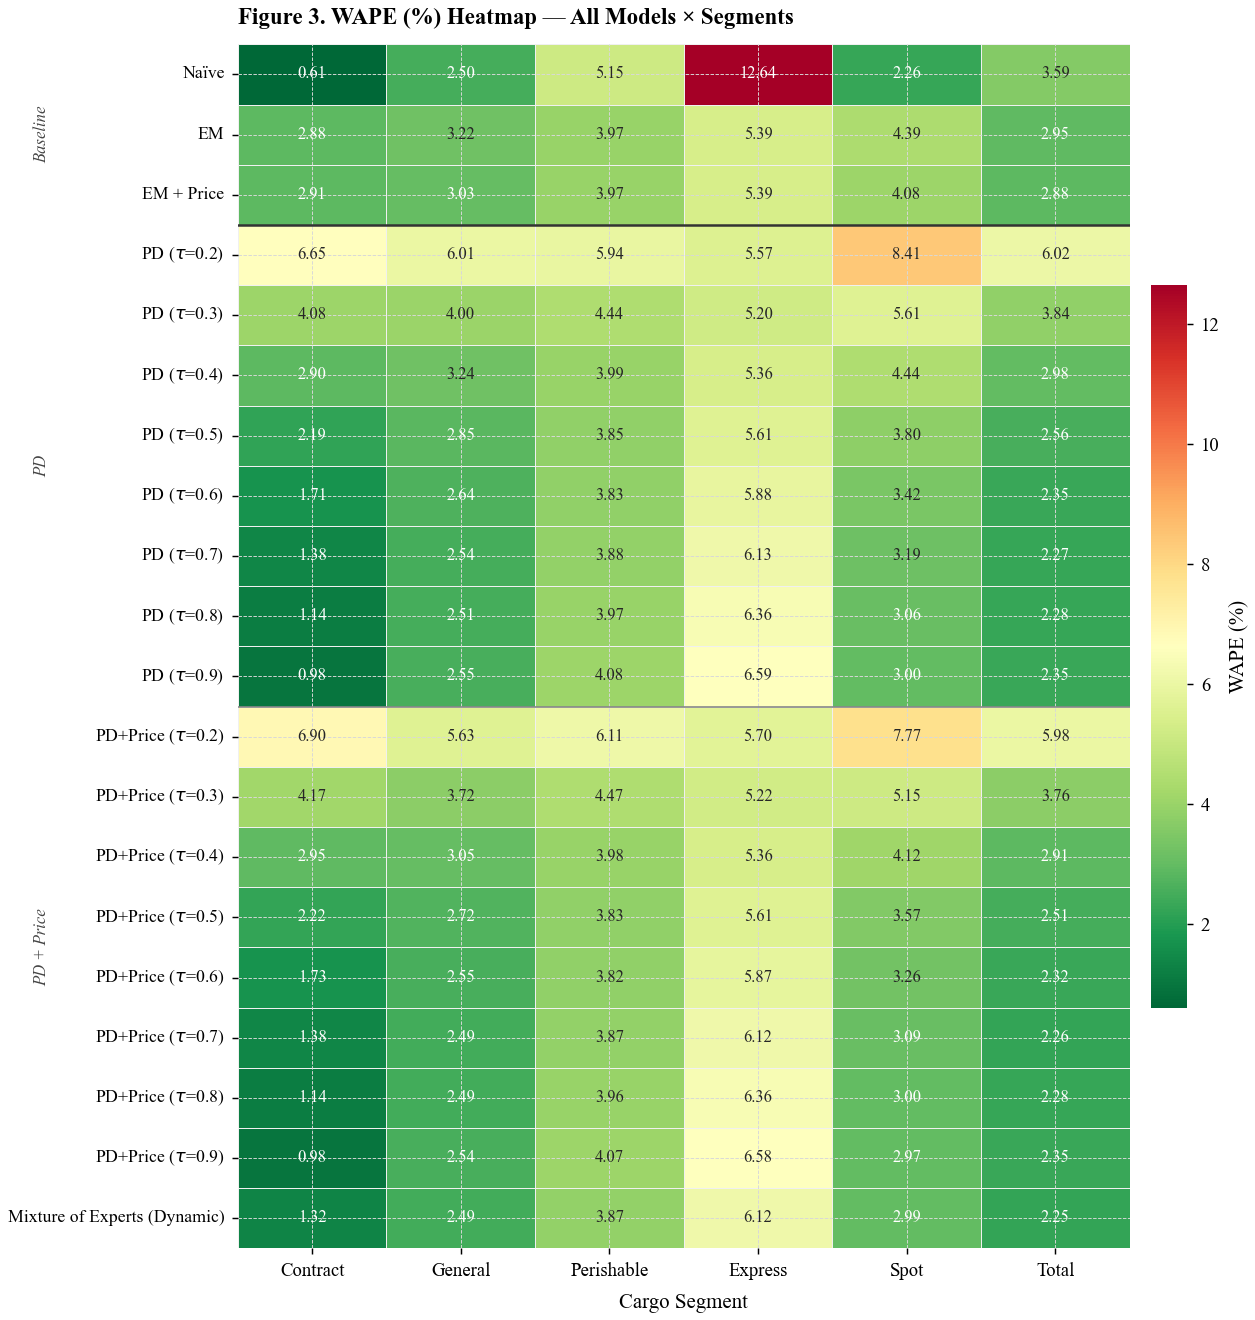

In [9]:
heatmap_data = (
    summary_df
    .reset_index()
    .pivot(index="Model", columns="Segment", values="WAPE")
    [EVAL_SEGMENTS]
)

# Order rows: baselines first, then PD by tau, then PDXPrice by tau
row_order = ["Naive", "EM", "EMXPrice"] + \
            [f"PD{str(t).replace('.','')}" for t in TAU_VALUES] + \
            [f"PDXPrice{str(t).replace('.','')}" for t in TAU_VALUES] + \
            ["MoE"]
row_order = [r for r in row_order if r in heatmap_data.index]
heatmap_data = heatmap_data.loc[row_order]

# Friendly row labels
row_labels = [MODEL_LABELS.get(m, m) for m in row_order]

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(
    heatmap_data, ax=ax,
    cmap="RdYlGn_r",
    annot=True, fmt=".2f", annot_kws={"size": 8},
    linewidths=0.4, linecolor="#f0f0f0",
    cbar_kws={"label": "WAPE (%)", "shrink": 0.6, "pad": 0.02},
    yticklabels=row_labels,
)

# Section separators
ax.axhline(3,  color="#333333", linewidth=1.2)   # after baselines
ax.axhline(11, color="#888888", linewidth=0.8)   # after PD family

ax.set_title("Figure 3. WAPE (%) Heatmap — All Models × Segments",
             loc="left", pad=10)
ax.set_xlabel("Cargo Segment", labelpad=6)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8.5, rotation=0)
ax.tick_params(axis="x", labelsize=9)

# Section labels
for y, label in [(1.5, "Baseline"), (7, "PD"), (15, "PD + Price")]:
    ax.text(-0.22, y, label, transform=ax.get_yaxis_transform(),
            ha="center", va="center", fontsize=8, color="#444444",
            style="italic", rotation=90)

plt.tight_layout()
plt.savefig("fig3_wape_heatmap_2dim.pdf")
plt.show()

---
## 9 · Figure 4: Model Effectiveness vs. Route Demand Volume

Each point represents one O–D route. LOESS trendlines reveal whether model accuracy degrades on high-volume routes.

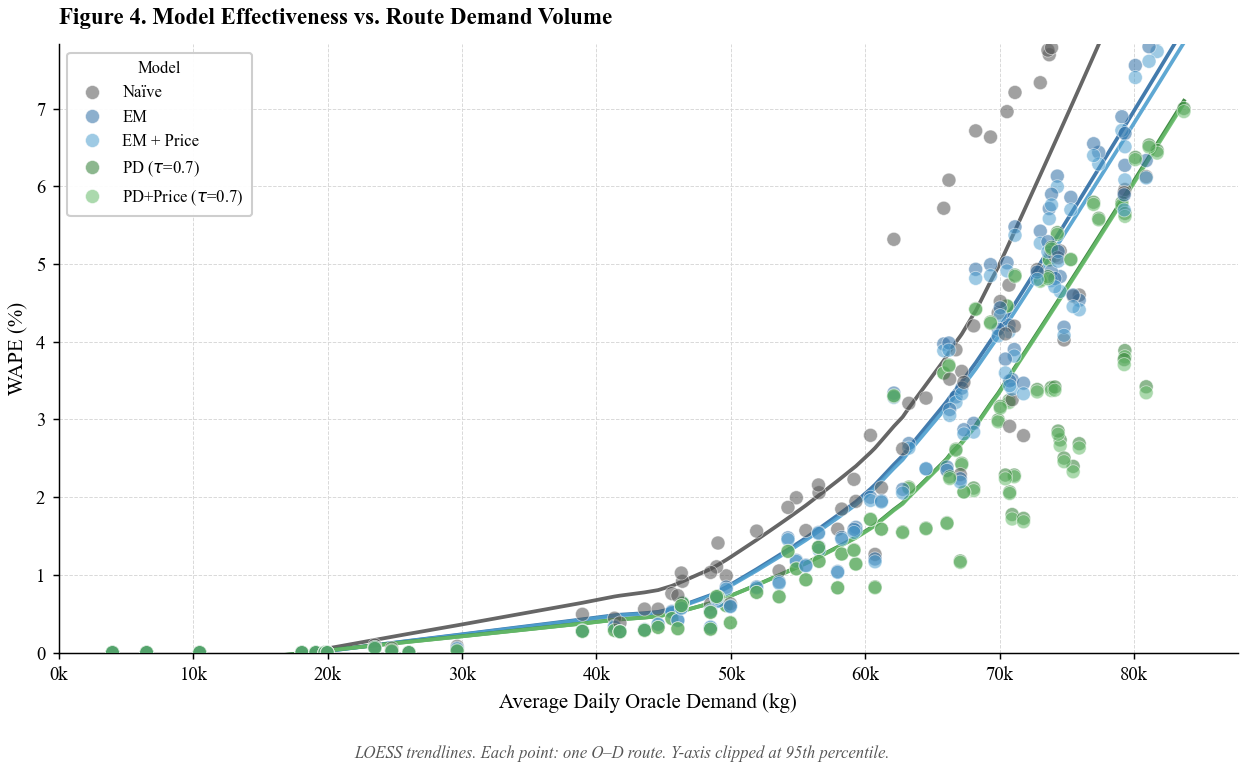

In [10]:
scatter_models = ["Naive", "EM", "EMXPrice", "PD07", "PDXPrice07"]
scatter_palette = {m: MODEL_PALETTE[m] for m in scatter_models}

scatter_data = df_route_metrics[
    (df_route_metrics["Segment"] == "Total") &
    (df_route_metrics["Model"].isin(scatter_models))
].copy()

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.set_axisbelow(True)

sns.scatterplot(
    data=scatter_data, x="Avg_Oracle_Demand", y="WAPE",
    hue="Model", palette=scatter_palette,
    alpha=0.55, edgecolor="w", linewidth=0.4, s=45, ax=ax, zorder=3,
)

# LOESS trendlines
for model in scatter_models:
    mdl = scatter_data[scatter_data["Model"] == model]
    sns.regplot(data=mdl, x="Avg_Oracle_Demand", y="WAPE",
                scatter=False, lowess=True, ax=ax,
                line_kws={"color": scatter_palette[model], "lw": 1.8, "alpha": 0.9},
                label="_nolegend_")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_ylim(0, scatter_data["WAPE"].quantile(0.95) * 1.1)
ax.set_xlabel("Average Daily Oracle Demand (kg)")
ax.set_ylabel("WAPE (%)")
ax.set_title("Figure 4. Model Effectiveness vs. Route Demand Volume",
             loc="left", pad=10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [MODEL_LABELS.get(l, l) for l in labels],
          title="Model", title_fontsize=8, fontsize=8)
fig.text(0.5, -0.03,
         "LOESS trendlines. Each point: one O–D route. Y-axis clipped at 95th percentile.",
         ha="center", fontsize=8, color="#555555", style="italic")
plt.tight_layout()
plt.savefig("fig4_volume_vs_wape_2dim.pdf")
plt.show()

---
## 10 · Figure 5: WAPE Distribution by Segment — Box-and-Strip Plots

Route-level WAPE distributions for selected models reveal per-segment heterogeneity.

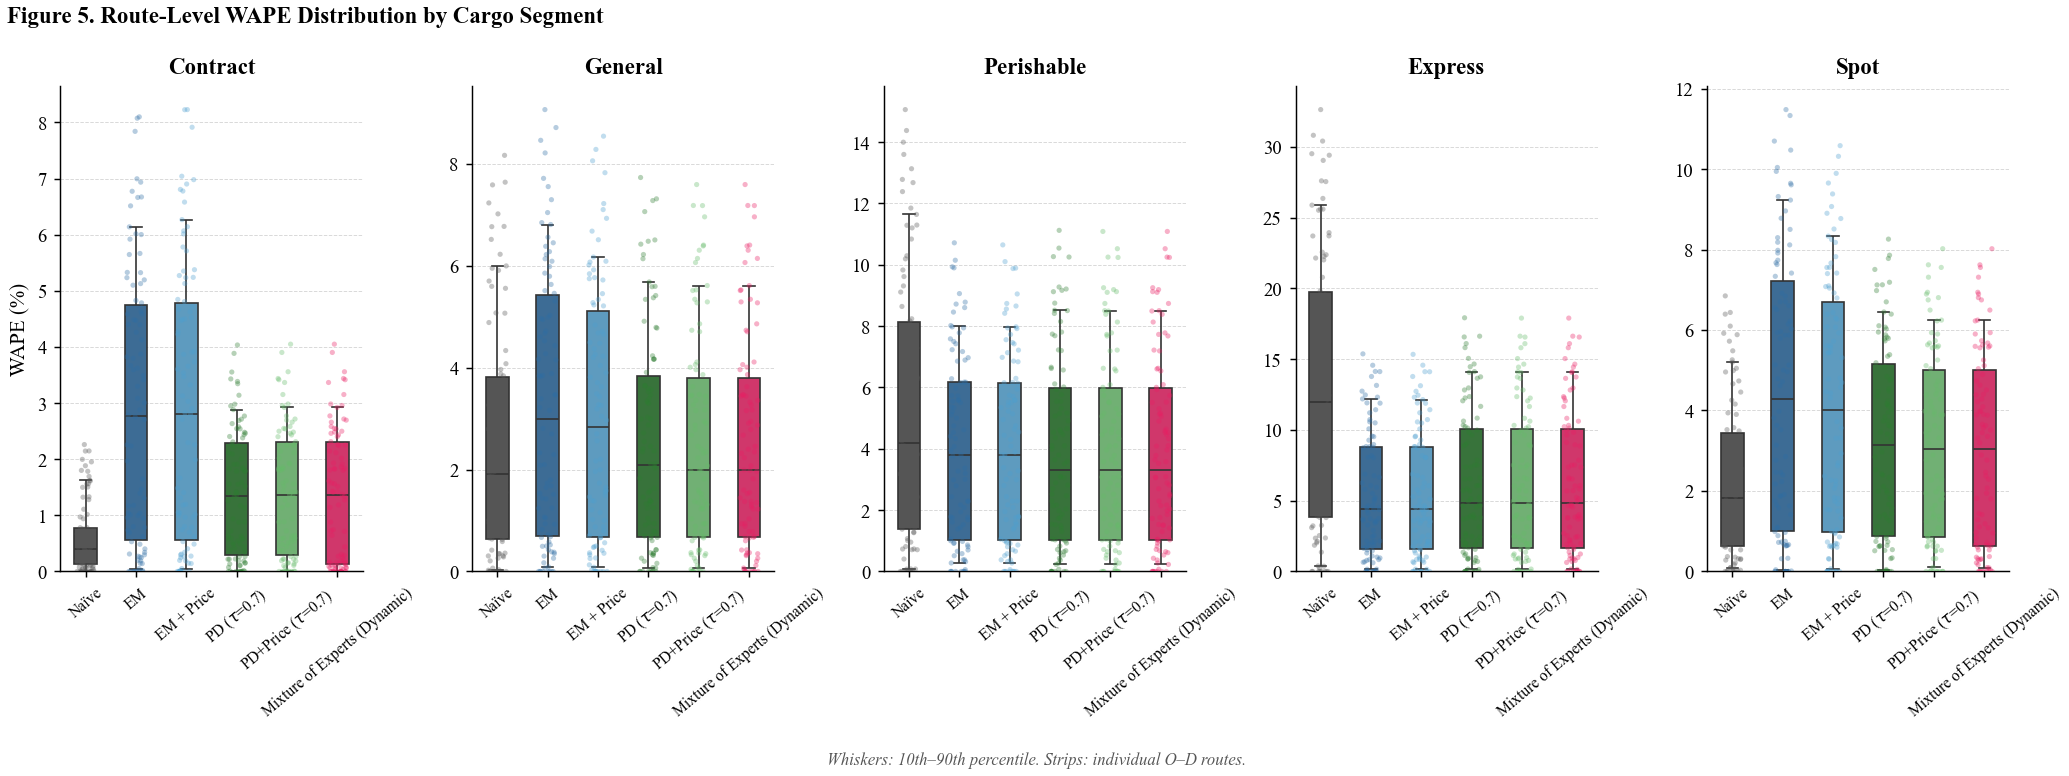

In [11]:
box_models = ["Naive", "EM", "EMXPrice", "PD07", "PDXPrice07", "MoE"]
box_data   = df_route_metrics[
    (df_route_metrics["Model"].isin(box_models)) &
    (df_route_metrics["Segment"].isin(SEGMENTS))
].copy()
box_data["Model_Label"] = box_data["Model"].map(MODEL_LABELS)

fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(14, 5), sharey=False)

for ax, seg in zip(axes, SEGMENTS):
    seg_data = box_data[box_data["Segment"] == seg]
    model_order  = box_models
    label_order  = [MODEL_LABELS[m] for m in model_order]
    color_order  = [MODEL_PALETTE[m] for m in model_order]

    sns.boxplot(
        data=seg_data, x="Model_Label", y="WAPE",
        order=label_order, palette=dict(zip(label_order, color_order)),
        width=0.45, fliersize=0, linewidth=0.8,
        whis=[10, 90], ax=ax, zorder=3,
    )
    sns.stripplot(
        data=seg_data, x="Model_Label", y="WAPE",
        order=label_order, palette=dict(zip(label_order, color_order)),
        size=2.5, alpha=0.35, jitter=0.18, ax=ax, zorder=4,
    )

    ax.set_title(seg, pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("WAPE (%)" if ax == axes[0] else "")
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", labelrotation=40, labelsize=7.5)
    ax.set_axisbelow(True)

fig.suptitle("Figure 5. Route-Level WAPE Distribution by Cargo Segment",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
fig.text(0.5, -0.03,
         "Whiskers: 10th–90th percentile. Strips: individual O–D routes.",
         ha="center", fontsize=8, color="#555555", style="italic")
plt.tight_layout()
plt.savefig("fig5_wape_distribution_2dim.pdf")
plt.show()

---
## 11 · Figure 6: Metric Radar Chart — Selected Models

Radar (spider) chart for holistic comparison of model strengths and trade-offs across four normalised metrics.

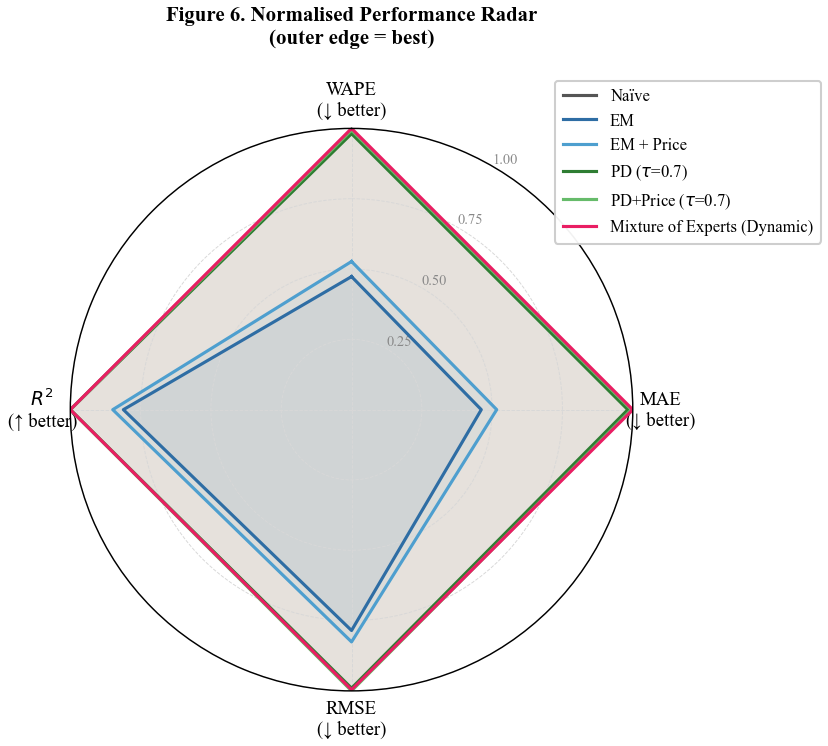

In [12]:
radar_models  = ["Naive", "EM", "EMXPrice", "PD07", "PDXPrice07", "MoE"]
radar_metrics = ["WAPE", "MAE", "RMSE", "R2"]
radar_invert  = {"R2": True}   # Higher R² is better, so invert before normalising

radar_df = global_total.loc[radar_models, radar_metrics].copy()

# Normalise to [0, 1] where 0 = worst, 1 = best
norm_df = radar_df.copy()
for col in radar_metrics:
    lo, hi = radar_df[col].min(), radar_df[col].max()
    if col in radar_invert:
        norm_df[col] = (radar_df[col] - lo) / (hi - lo)          # higher → better
    else:
        norm_df[col] = 1 - (radar_df[col] - lo) / (hi - lo)     # lower → better

N       = len(radar_metrics)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(30)
ax.set_ylim(0, 1)
ax.yaxis.set_tick_params(labelsize=7)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], color="#888888", size=7)

for model in radar_models:
    values  = norm_df.loc[model].tolist()
    values += values[:1]
    color   = MODEL_PALETTE.get(model, "#888888")
    ax.plot(angles, values, linewidth=1.5, color=color, label=MODEL_LABELS.get(model, model))
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    ["WAPE\n(↓ better)", "MAE\n(↓ better)", "RMSE\n(↓ better)", "$R^2$\n(↑ better)"],
    size=9
)
ax.set_title("Figure 6. Normalised Performance Radar\n(outer edge = best)",
             pad=18, fontsize=10, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig("fig6_radar_2dim.pdf")
plt.show()

---
## 12 · Figure 7: PD vs PD+Price — Fractile-Level Improvement

For each $\tau$, the difference $\Delta$WAPE = WAPE(PD) − WAPE(PD+Price). Positive values indicate that adding price information reduces error.

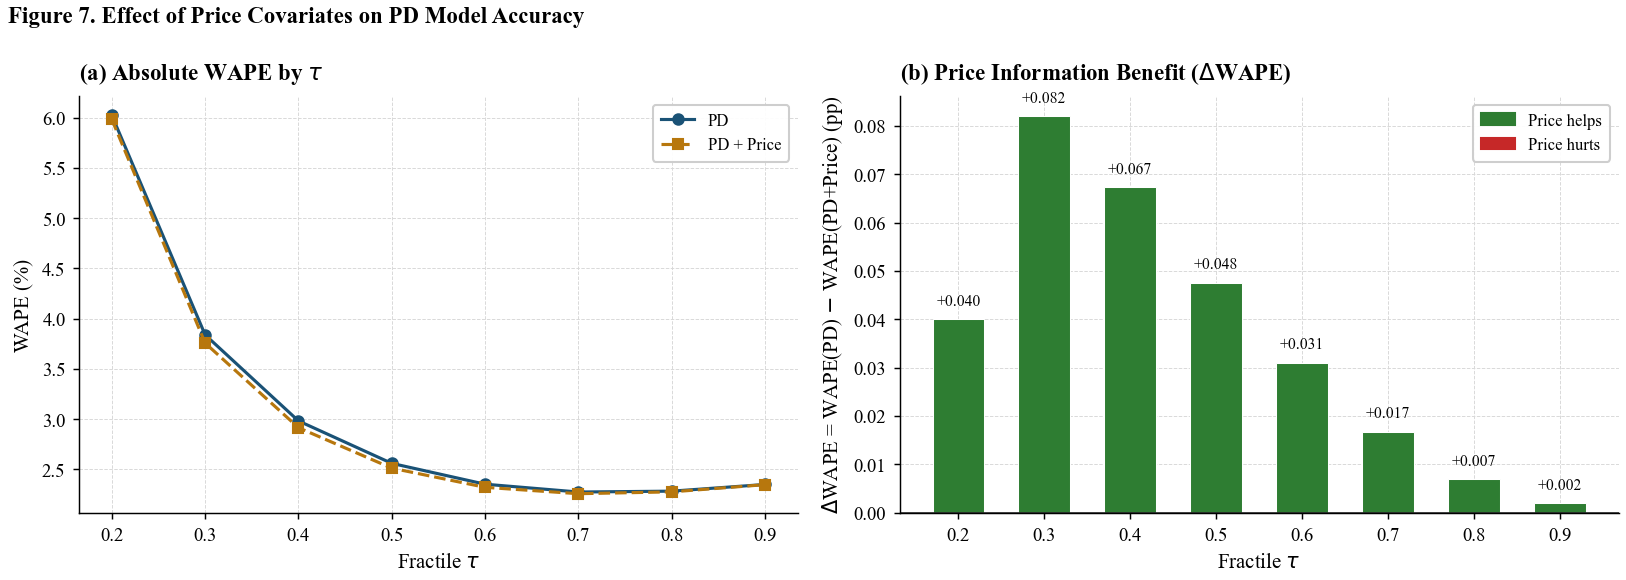

In [13]:
pd_wide = pd_metrics.pivot(index="Tau", columns="Model_Type", values="WAPE")
pd_wide["Delta_WAPE"] = pd_wide["PD"] - pd_wide["PD + Price"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: absolute WAPE
ax = axes[0]
ax.plot(pd_wide.index, pd_wide["PD"], "-o", color="#1a5276",
        markersize=5, lw=1.5, label="PD")
ax.plot(pd_wide.index, pd_wide["PD + Price"], "--s", color="#b7770d",
        markersize=5, lw=1.5, label="PD + Price")
ax.set_xlabel("Fractile $\\tau$")
ax.set_ylabel("WAPE (%)")
ax.set_title("(a) Absolute WAPE by $\\tau$", loc="left")
ax.set_xticks(TAU_VALUES)
ax.legend(fontsize=8)
ax.set_axisbelow(True)

# Right: delta
ax = axes[1]
bar_colors = ["#2e7d32" if v >= 0 else "#c62828" for v in pd_wide["Delta_WAPE"]]
bars = ax.bar(pd_wide.index, pd_wide["Delta_WAPE"],
              width=0.06, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="#333333", linewidth=0.8)
for bar, val in zip(bars, pd_wide["Delta_WAPE"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.002 * np.sign(val),
            f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top",
            fontsize=7.5)
ax.set_xlabel("Fractile $\\tau$")
ax.set_ylabel("$\\Delta$WAPE = WAPE(PD) $-$ WAPE(PD+Price) (pp)")
ax.set_title("(b) Price Information Benefit ($\\Delta$WAPE)", loc="left")
ax.set_xticks(TAU_VALUES)
green_patch = mpatches.Patch(color="#2e7d32", label="Price helps")
red_patch   = mpatches.Patch(color="#c62828", label="Price hurts")
ax.legend(handles=[green_patch, red_patch], fontsize=8)
ax.set_axisbelow(True)

fig.suptitle("Figure 7. Effect of Price Covariates on PD Model Accuracy",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("fig7_price_benefit_2dim.pdf")
plt.show()

---
## 13 · Figure 8: Time-Series — PEK → LAX (PDXPrice08)

Segment-level time-series for the PEK→LAX route using the best-performing model, showing true demand, truncated observations, and model estimates.

date range in slice: 2016-01-01 to 2018-12-31


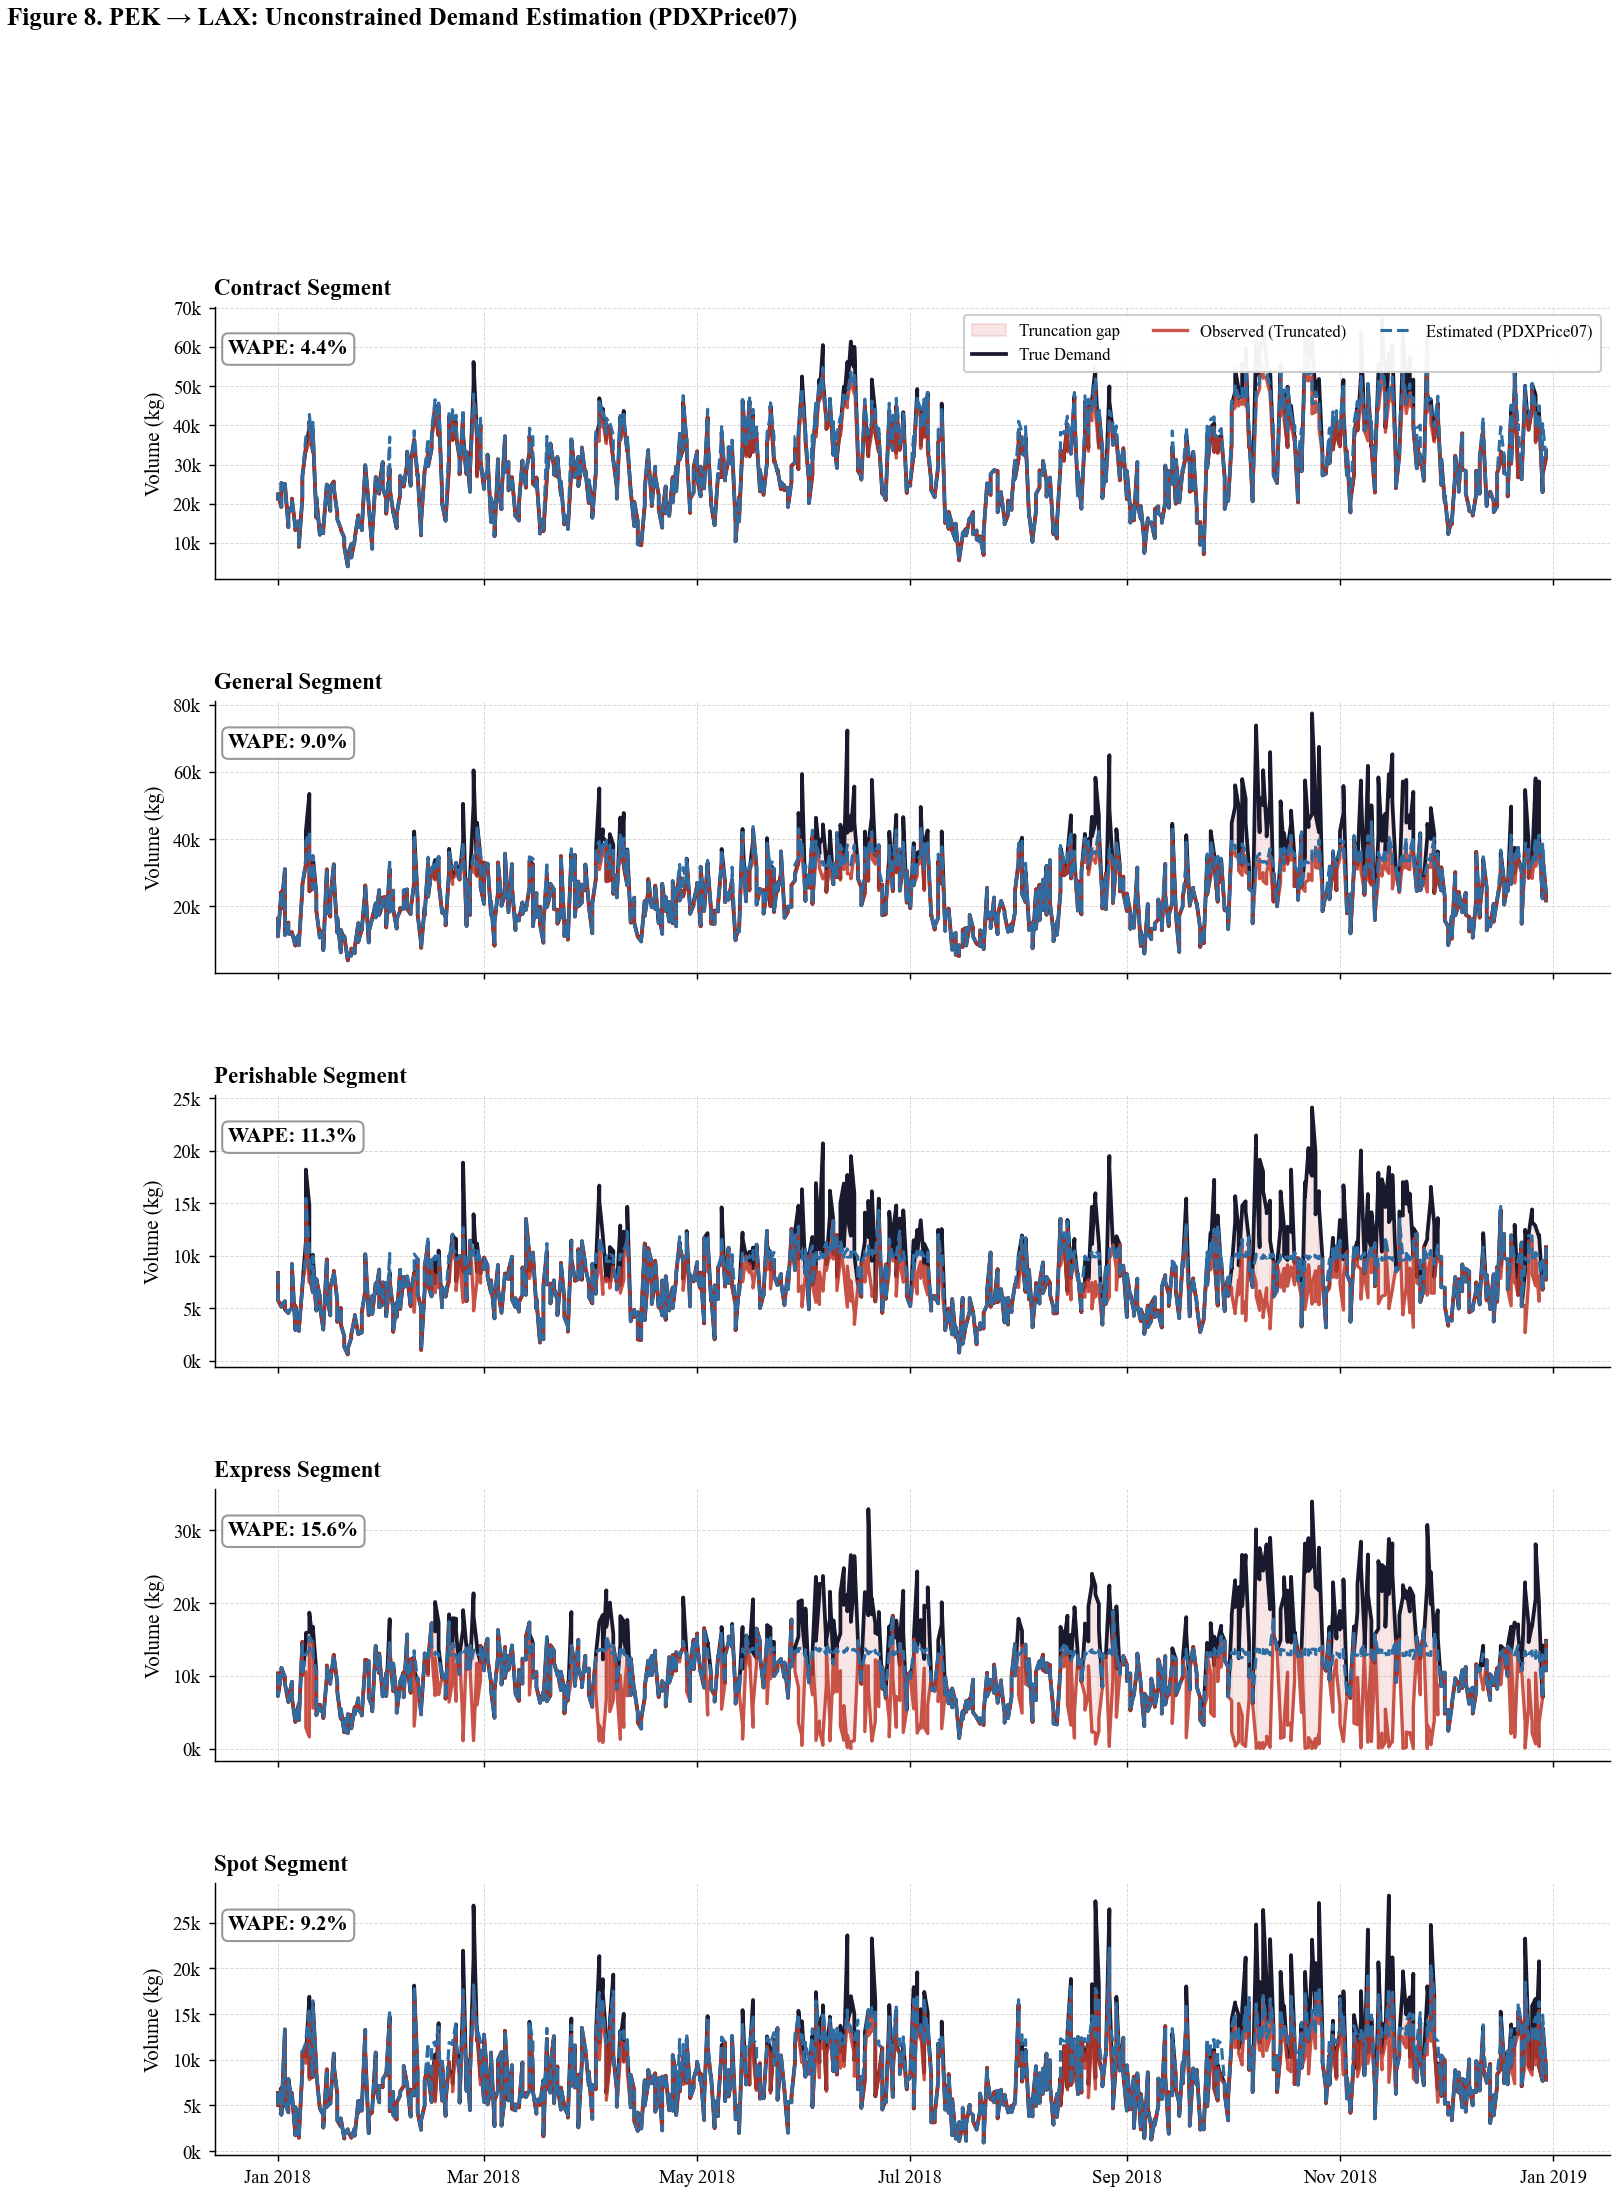

In [14]:
import numpy as np

MODEL_TO_PLOT = "PDXPrice07"
ORIGIN, DEST  = "PEK", "LAX"
DATE_START, DATE_END = "2018-01-01", "2018-12-31"

viz_slice = df_analysis[
    (df_analysis["Origin"] == ORIGIN) & (df_analysis["Destination"] == DEST)
].copy()
viz_slice["Date"] = pd.to_datetime(viz_slice["Date"])

print(f'date range in slice: {viz_slice["Date"].min().date()} to {viz_slice["Date"].max().date()}')

viz_slice = viz_slice[
    (viz_slice["Date"] >= DATE_START) & (viz_slice["Date"] < DATE_END)
].sort_values("Date")

fig = plt.figure(figsize=(12, 3.2 * len(SEGMENTS)))
gs  = gridspec.GridSpec(len(SEGMENTS), 1, hspace=0.45)

for i, seg in enumerate(SEGMENTS):
    ax = fig.add_subplot(gs[i])

    dates  = viz_slice["Date"].values
    y_true = viz_slice[f"Oracle_{seg}_kg"].values
    y_obs  = viz_slice[f"Observed_{seg}_kg"].values
    y_pred = viz_slice[f"{MODEL_TO_PLOT}_{seg}_Est_kg"].values

    ax.set_axisbelow(True)

    # Truncation shading
    trunc = y_true > y_obs
    ax.fill_between(dates, y_obs, y_true, where=trunc,
                    color=TS_COLORS["Observed"], alpha=0.12,
                    label="Truncation gap" if i == 0 else "_")

    ax.plot(dates, y_true, color=TS_COLORS["Oracle"],
            lw=1.8, label="True Demand" if i == 0 else "_")
    ax.plot(dates, y_obs,  color=TS_COLORS["Observed"],
            lw=1.6, linestyle="-", alpha=0.85,
            label="Observed (Truncated)" if i == 0 else "_")
    ax.plot(dates, y_pred, color=TS_COLORS["Estimate"],
            lw=1.5, linestyle="--",
            label=f"Estimated ({MODEL_TO_PLOT})" if i == 0 else "_")

    # --- NEW: Calculate and display WAPE ---
    # WAPE = sum(|True - Pred|) / sum(True)
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
    
    # Display as a text box in the upper left corner
    ax.text(0.01, 0.88, f"WAPE: {wape:.1%}", 
            transform=ax.transAxes, 
            fontsize=10, 
            fontweight='bold',
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))
    # ---------------------------------------

    ax.set_title(f"{seg} Segment", loc="left", pad=6)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
    ax.set_ylabel("Volume (kg)")

    if i == 0:
        ax.legend(loc="upper right", fontsize=8, ncol=3)

    if i < len(SEGMENTS) - 1:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax.tick_params(axis="x", rotation=0)

fig.suptitle(
    f"Figure 8. {ORIGIN} → {DEST}: Unconstrained Demand Estimation ({MODEL_TO_PLOT})",
    x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.005
)
plt.savefig("fig8_timeseries_pek_lax_2dim.pdf", bbox_inches="tight")
plt.show()

---
## 14 · Figure 9: Segment-Level WAPE Comparison — Grouped Bar Chart

Facilitates direct segment-by-segment comparison for the selected model set.

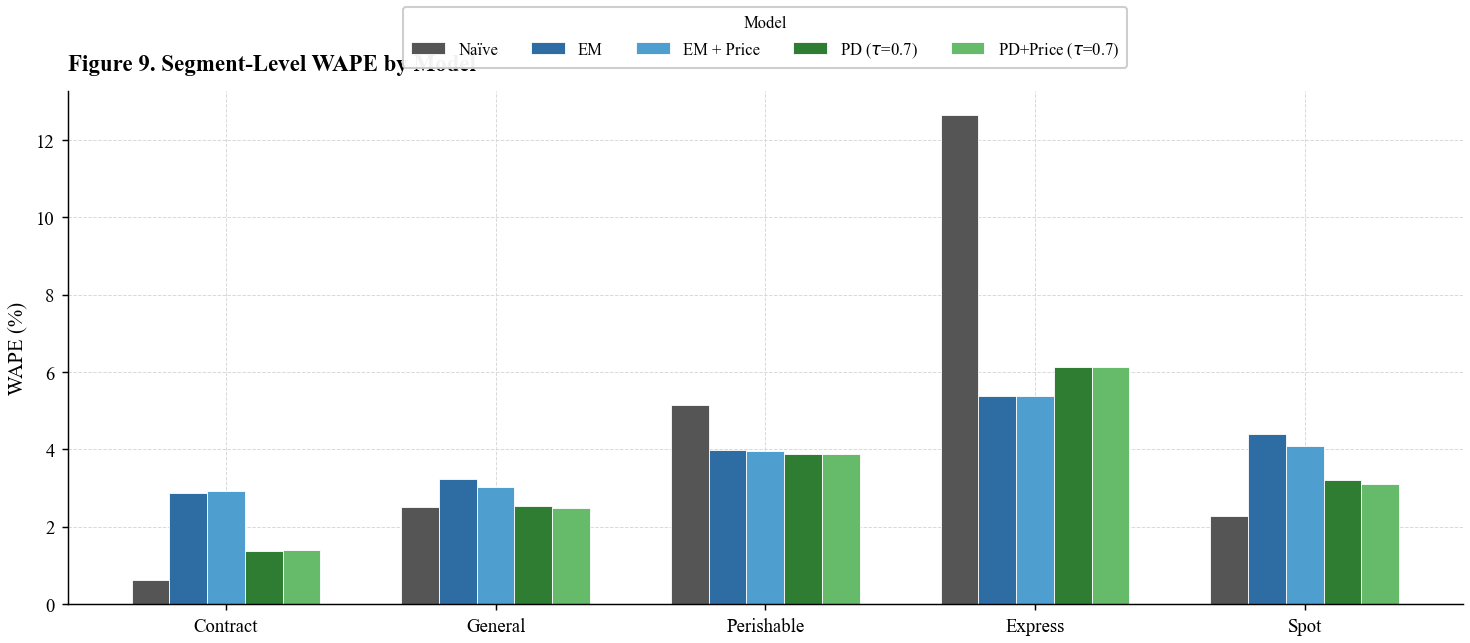

In [15]:
grouped_models = ["Naive", "EM", "EMXPrice", "PD07", "PDXPrice07"]
grouped_segs   = SEGMENTS  # Exclude Total for per-segment readability

grouped_data = (
    summary_df
    .reset_index()
    .query("Model in @grouped_models and Segment in @grouped_segs")
    .pivot(index="Segment", columns="Model", values="WAPE")
    [grouped_models]
    .loc[grouped_segs]
)

n_segs   = len(grouped_segs)
n_models = len(grouped_models)
x        = np.arange(n_segs)
width    = 0.14
offsets  = np.linspace(-(n_models - 1) / 2 * width, (n_models - 1) / 2 * width, n_models)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.set_axisbelow(True)

for j, (model, offset) in enumerate(zip(grouped_models, offsets)):
    vals = grouped_data[model].values
    bars = ax.bar(x + offset, vals, width=width,
                  color=MODEL_PALETTE[model], edgecolor="white",
                  linewidth=0.4, label=MODEL_LABELS.get(model, model))

ax.set_xticks(x)
ax.set_xticklabels(grouped_segs)
ax.set_ylabel("WAPE (%)")
ax.set_title("Figure 9. Segment-Level WAPE by Model", loc="left", pad=10)
ax.legend(title="Model", title_fontsize=8, fontsize=8, ncol=len(grouped_models),
          loc="upper center", bbox_to_anchor=(0.5, 1.18))
plt.tight_layout()
plt.savefig("fig9_grouped_wape_2dim.pdf")
plt.show()

---
## 14 · Mixture of Experts (MoE) Selection Analysis

Analyzing the distribution of models selected by the MoE (Dynamic) logic across different segments and O-D pairs.

In [16]:
selection_cols = [c for c in df_analysis.columns if "_Selected_Model" in c]
if selection_cols:
    selection_data = []
    for col in selection_cols:
        seg = col.split("_")[1]
        counts = df_analysis[col].value_counts()
        for model, count in counts.items():
            selection_data.append({"Segment": seg, "Model": model, "Count": count})
    
    df_selection = pd.DataFrame(selection_data)
    df_selection_pivot = df_selection.pivot(index="Model", columns="Segment", values="Count").fillna(0)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(df_selection_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
    ax.set_title("Figure 10. MoE Selection Distribution by Segment", loc="left", pad=10)
    plt.tight_layout()
    plt.savefig("fig10_moe_selection_heatmap.pdf")
    plt.show()
else:
    print("MoE selection data not found. Ensure moe_selection.py has been run.")

ValueError: Index contains duplicate entries, cannot reshape

---
## 15 · Summary: Key Findings

| Finding | Detail |
|---|---|
| **Best overall model** | PD+Price at $\tau \approx 0.7$–$0.8$ consistently achieves lowest WAPE and highest $R^2$ |
| **MoE Selection** | Dynamic model selection (MoE) using pseudo-censoring validation effectively picks segment-optimal models without oracle access |
| **Price information** | Adding price covariates improves accuracy at most $\tau$ levels (positive $\Delta$WAPE) |
| **Fractile sensitivity** | Very low $\tau$ (0.2) severely degrades performance; performance stabilises above $\tau = 0.6$ |
| **Naïve model** | Surprisingly competitive on Contract and Spot segments; fails on Express |
| **EM baseline** | Robust across segments, good default when $\tau$ tuning is not feasible |
| **Volume effect** | WAPE increases with route volume; all models degrade on high-volume routes |